In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
# Raw listings scraped from zameen.com/Houses_Property/Faisalabad-16-{1,2}.html
# Each tuple: (location/society, wider_area, size, size_unit, price, price_unit, zameen_listing_id)
listings = [
    ("Eden Valley", "Faisalabad", 5, "Marla", 2.65, "Crore", "54611735"),
    ("Eden Valley", "Faisalabad", 5, "Marla", 2.6, "Crore", "54611731"),
    ("Eden Valley", "Faisalabad", 7, "Marla", 3.7, "Crore", "54611728"),
    ("Eden Executive", "Eden Gardens", 5, "Marla", 2.6, "Crore", "54611725"),
    ("Eden Executive", "Eden Gardens", 5, "Marla", 2.3, "Crore", "54614817"),
    ("Eden Valley", "Faisalabad", 5, "Marla", 2.65, "Crore", "54622884"),
    ("Abdullah Gardens", "East Canal Road", 20, "Marla", 14.0, "Crore", "54496692"),
    ("Eden Orchard", "Faisalabad", 5, "Marla", 2.7, "Crore", "54575043"),
    ("Al Najaf Colony", "Faisalabad", 2.5, "Marla", 1.5, "Crore", "54615181"),
    ("Divine Enclave", "Canal Road", 13, "Marla", 6.5, "Crore", "54571147"),
    ("Khayaban Colony 2", "Faisalabad", 22, "Marla", 5.6, "Crore", "53657911"),
    ("Model City 1", "Canal Road", 7, "Marla", 3.5, "Crore", "54306077"),
    ("Model City 1", "Canal Road", 3, "Marla", 1.28, "Crore", "54571133"),
    ("Eden Executive", "Eden Gardens", 5, "Marla", 2.1, "Crore", "54571121"),
    ("Eden Valley", "Faisalabad", 7, "Marla", 3.6, "Crore", "53493139"),
    ("Eden Orchard", "Faisalabad", 11, "Marla", 6.0, "Crore", "54545939"),
    ("Canal Road", "Faisalabad", 7, "Marla", 2.5, "Crore", "53876022"),
    ("Model City 1", "Canal Road", 7, "Marla", 2.7, "Crore", "54622854"),
    ("Model City 1", "Canal Road", 3, "Marla", 1.35, "Crore", "54622697"),
    ("Kohinoor City", "Faisalabad", 16, "Marla", 8.5, "Crore", "54070243"),
    ("Citi Housing", "Faisalabad", 10, "Marla", 3.35, "Crore", "54588956"),
    ("Citi Housing", "Faisalabad", 10, "Marla", 3.0, "Crore", "54588985"),
    ("Citi Housing", "Faisalabad", 5, "Marla", 1.35, "Crore", "54588986"),
    ("Citi Housing Sargodha Road", "Citi Housing", 42, "Marla", 9.9, "Crore", "54588988"),
    ("Citi Housing Sargodha Road", "Citi Housing", 20, "Marla", 7.5, "Crore", "54588989"),
    ("Eden Valley", "Faisalabad", 7, "Marla", 4.25, "Crore", "54497801"),
    ("Eden Valley", "Faisalabad", 5, "Marla", 2.7, "Crore", "54497803"),
    ("Wapda City - Block M", "Wapda City", 10, "Marla", 4.75, "Crore", "54581736"),
    ("Eden Orchard", "Faisalabad", 5, "Marla", 2.4, "Crore", "54605383"),
    ("Divine Enclave", "Canal Road", 7, "Marla", 4.25, "Crore", "54600470"),
    ("Wapda City", "Faisalabad", 5, "Marla", 2.55, "Crore", "54428116"),
    ("Eden Orchard", "Faisalabad", 5, "Marla", 2.6, "Crore", "54494648"),
    ("Eden Orchard", "Faisalabad", 11, "Marla", 6.0, "Crore", "54604116"),
    ("Eden Orchard Block Y", "Eden Orchard", 5, "Marla", 2.8, "Crore", "54350345"),
    ("Jaranwala Road", "Faisalabad", 2.2, "Marla", 0.60, "Crore", "54518182"),
    ("Eden Valley", "Faisalabad", 6, "Marla", 3.6, "Crore", "54318366"),
    ("Eden Executive", "Eden Gardens", 7, "Marla", 2.75, "Crore", "54554089"),
    ("Eden Orchard", "Faisalabad", 5, "Marla", 2.25, "Crore", "54622431"),
    ("Al Najaf Colony", "Faisalabad", 10, "Marla", 5.0, "Crore", "54615268"),
    ("Peoples Colony - Block B", "Peoples Colony No 1", 7.5, "Marla", 5.0, "Crore", "54577386"),
    ("Eden Orchard", "Faisalabad", 5, "Marla", 2.6, "Crore", "54444126"),
    ("Satiana Road", "Faisalabad", 8, "Marla", 1.7, "Crore", "53055130"),
    ("Citi Housing Sargodha Road", "Citi Housing", 5, "Marla", 1.55, "Crore", "54588990"),
    ("Citi Housing Sargodha Road", "Citi Housing", 20, "Marla", 10.0, "Crore", "54588991"),
    ("Divine Enclave", "Canal Road", 7, "Marla", 4.25, "Crore", "54619730"),
    ("Eden Executive", "Eden Gardens", 5, "Marla", 2.3, "Crore", "54619728"),
    ("Eden Executive", "Eden Gardens", 2.7, "Marla", 1.25, "Crore", "54619727"),
    ("Model City 1", "Canal Road", 5, "Marla", 1.85, "Crore", "54619726"),
    ("Abdullah Gardens", "East Canal Road", 7, "Marla", 4.0, "Crore", "54619723"),
    ("Eden Executive", "Eden Gardens", 7, "Marla", 3.5, "Crore", "54595655"),
]

rows = []
for loc, area, size_val, size_unit, price_val, price_unit, listing_id in listings:
    marla = size_val * 20 if size_unit == "Kanal" else size_val   # 1 Kanal = 20 Marla
    sqft = marla * 225                                             # 1 Marla ~= 225 sq ft
    price_pkr = price_val * 1e7 if price_unit == "Crore" else price_val * 1e5
    rows.append({
        "Location": loc, "Wider_Area": area,
        "Size_Marla": marla, "Size_Sqft": sqft,
        "Price_PKR": price_pkr, "Zameen_Listing_ID": listing_id
    })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} real listings")
df.head(10)

Loaded 50 real listings


,Location,Wider_Area,Size_Marla,Size_Sqft,Price_PKR,Zameen_Listing_ID
0,Eden Valley,Faisalabad,5.0,1125.0,26500000.0,54611735
1,Eden Valley,Faisalabad,5.0,1125.0,26000000.0,54611731
2,Eden Valley,Faisalabad,7.0,1575.0,37000000.0,54611728
3,Eden Executive,Eden Gardens,5.0,1125.0,26000000.0,54611725
4,Eden Executive,Eden Gardens,5.0,1125.0,23000000.0,54614817
5,Eden Valley,Faisalabad,5.0,1125.0,26500000.0,54622884
6,Abdullah Gardens,East Canal Road,20.0,4500.0,140000000.0,54496692
7,Eden Orchard,Faisalabad,5.0,1125.0,27000000.0,54575043
8,Al Najaf Colony,Faisalabad,2.5,562.5,15000000.0,54615181
9,Divine Enclave,Canal Road,13.0,2925.0,65000000.0,54571147


In [3]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nRows with price <= 0 or size <= 0:", ((df["Price_PKR"] <= 0) | (df["Size_Marla"] <= 0)).sum())
print("Duplicate rows:", df.duplicated(subset=["Location","Size_Marla","Price_PKR"]).sum())
print(df[["Size_Marla","Size_Sqft","Price_PKR"]].describe())

df_clean = df.copy()  # nothing to drop — scraped active, well-formed listings only

Missing values per column:
Location             0
Wider_Area           0
Size_Marla           0
Size_Sqft            0
Price_PKR            0
Zameen_Listing_ID    0
dtype: int64

Rows with price <= 0 or size <= 0: 0
Duplicate rows: 5
       Size_Marla    Size_Sqft     Price_PKR
count   50.000000    50.000000  5.000000e+01
mean     8.338000  1876.050000  3.758600e+07
std      6.731767  1514.647623  2.571199e+07
min      2.200000   495.000000  6.000000e+06
25%      5.000000  1125.000000  2.325000e+07
50%      7.000000  1575.000000  2.725000e+07
75%      9.500000  2137.500000  4.250000e+07
max     42.000000  9450.000000  1.400000e+08


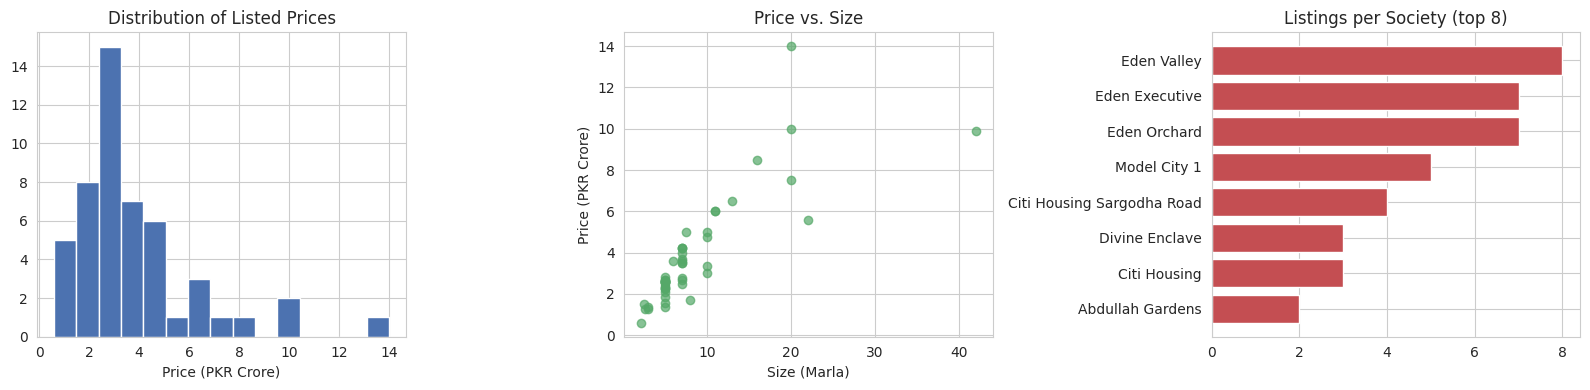

Location
Peoples Colony - Block B    6.666667
Abdullah Gardens            6.357143
Divine Enclave              5.714286
Eden Orchard Block Y        5.600000
Al Najaf Colony             5.500000
Eden Valley                 5.462500
Kohinoor City               5.312500
Eden Orchard                5.144156
Wapda City                  5.100000
Wapda City - Block M        4.750000
Name: Price_per_Marla, dtype: float64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].hist(df_clean["Price_PKR"] / 1e7, bins=15, color="#4C72B0", edgecolor="white")
axes[0].set_xlabel("Price (PKR Crore)"); axes[0].set_title("Distribution of Listed Prices")

axes[1].scatter(df_clean["Size_Marla"], df_clean["Price_PKR"] / 1e7, alpha=0.7, color="#55A868")
axes[1].set_xlabel("Size (Marla)"); axes[1].set_ylabel("Price (PKR Crore)"); axes[1].set_title("Price vs. Size")

top_locs = df_clean["Location"].value_counts().head(8)
axes[2].barh(top_locs.index[::-1], top_locs.values[::-1], color="#C44E52")
axes[2].set_title("Listings per Society (top 8)")
plt.tight_layout(); plt.show()

df_clean["Price_per_Marla"] = df_clean["Price_PKR"] / df_clean["Size_Marla"]
print(df_clean.groupby("Location")["Price_per_Marla"].mean().sort_values(ascending=False).head(10) / 1e6)

In [5]:
loc_counts = df_clean["Location"].value_counts()
common_locations = loc_counts[loc_counts >= 3].index.tolist()
print("Kept as own category (>=3 listings):", common_locations)

df_clean["Location_Grouped"] = df_clean["Location"].where(
    df_clean["Location"].isin(common_locations), "Other"
)
print(df_clean["Location_Grouped"].value_counts())

Kept as own category (>=3 listings): ['Eden Valley', 'Eden Executive', 'Eden Orchard', 'Model City 1', 'Citi Housing Sargodha Road', 'Divine Enclave', 'Citi Housing']
Location_Grouped
Other                         13
Eden Valley                    8
Eden Executive                 7
Eden Orchard                   7
Model City 1                   5
Citi Housing Sargodha Road     4
Divine Enclave                 3
Citi Housing                   3
Name: count, dtype: int64


In [6]:
X = df_clean[["Size_Sqft", "Location_Grouped"]]
y = df_clean["Price_PKR"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(
    transformers=[("location_ohe", OneHotEncoder(handle_unknown="ignore"), ["Location_Grouped"])],
    remainder="passthrough"
)
model = Pipeline([("preprocess", preprocessor), ("regressor", LinearRegression())])
model.fit(X_train, y_train)
print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")

Train rows: 40, Test rows: 10


TRAIN  MSE: 214,244,882,332,828  (RMSE: PKR 14,637,106)  R²: 0.700
TEST   MSE: 99,329,702,061,415  (RMSE: PKR 9,966,429)  R²: 0.734


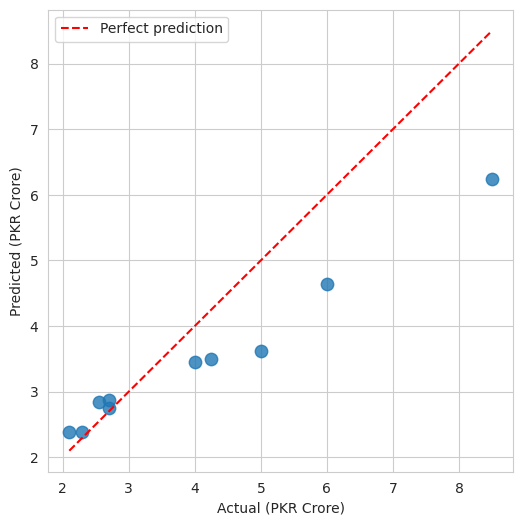

In [7]:
y_pred_train = model.predict(X_train)
y_pred_test = model.predict(X_test)

train_mse, test_mse = mean_squared_error(y_train, y_pred_train), mean_squared_error(y_test, y_pred_test)
train_r2, test_r2 = r2_score(y_train, y_pred_train), r2_score(y_test, y_pred_test)

print(f"TRAIN  MSE: {train_mse:,.0f}  (RMSE: PKR {np.sqrt(train_mse):,.0f})  R²: {train_r2:.3f}")
print(f"TEST   MSE: {test_mse:,.0f}  (RMSE: PKR {np.sqrt(test_mse):,.0f})  R²: {test_r2:.3f}")

fig, ax = plt.subplots(figsize=(6,6))
ax.scatter(y_test/1e7, y_pred_test/1e7, s=80, alpha=0.8)
lims = [min(y_test.min(),y_pred_test.min())/1e7, max(y_test.max(),y_pred_test.max())/1e7]
ax.plot(lims, lims, "r--", label="Perfect prediction")
ax.set_xlabel("Actual (PKR Crore)"); ax.set_ylabel("Predicted (PKR Crore)"); ax.legend()
plt.show()

In [8]:
hypothetical = pd.DataFrame([
    {"description": "5 Marla in Eden Valley (well-represented)", "Size_Sqft": 5*225, "Location_Grouped": "Eden Valley"},
    {"description": "10 Marla in Wapda City (sparse society)", "Size_Sqft": 10*225,
     "Location_Grouped": "Wapda City" if "Wapda City" in common_locations else "Other"},
    {"description": "30 Marla in Eden Orchard (size extrapolation)", "Size_Sqft": 30*225, "Location_Grouped": "Eden Orchard"},
])
hypothetical["Predicted_Price_Crore"] = model.predict(hypothetical[["Size_Sqft","Location_Grouped"]]) / 1e7
hypothetical[["description","Predicted_Price_Crore"]]

,description,Predicted_Price_Crore
0,5 Marla in Eden Valley (well-represented),2.870559
1,10 Marla in Wapda City (sparse society),4.386717
2,30 Marla in Eden Orchard (size extrapolation),10.525014
